In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [3]:
!pip install xgboost joblib

In [4]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [5]:
from google.colab import files
#uploaded = files.upload()

In [6]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [7]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/data_final.csv")
df.head()

,elevation,slope,hor_dis_hydrology,ver_dis_hydrology,hor_dis_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,hor_dis_fire_points,cover_type,...,soil_type_31,soil_type_32,soil_type_33,soil_type_34,soil_type_35,soil_type_36,soil_type_37,soil_type_38,soil_type_39,soil_type_40
0,-1.422686,-1.469470,0.223470,-0.916250,-1.661258,0.152380,0.451589,0.264532,1.835567,0,...,False,False,False,False,False,False,False,False,False,False
1,-1.452980,-1.636015,-0.013935,-1.243327,-1.732357,0.101360,0.649543,0.363490,1.804918,0,...,False,False,False,False,False,False,False,False,False,False
2,-0.372506,-0.470197,0.272707,0.933755,-0.079292,0.815649,0.847497,-0.164286,1.745890,4,...,False,False,False,False,False,False,False,False,False,False
3,-0.468436,1.028712,0.143019,2.069054,-0.132617,1.019732,0.847497,-0.593104,1.796972,4,...,False,False,False,False,False,False,False,False,False,False
4,-1.427735,-1.636015,-0.352204,-0.964536,-1.731765,0.101360,0.583558,0.330504,1.774836,0,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df['soil_wilderness'] = df['soil_wilderness'].astype('float')

In [9]:
from google.colab import drive
drive.mount('full_pipeline.pkl', force_remount=True)


Mounted at full_pipeline.pkl


In [ ]:
#import joblib
#joblib.dump(pipeline, "/content/full_pipeline.pkl")'''

In [ ]:
#import joblib
#pipeline = joblib.load("/content/drive/MyDrive/full_pipeline.pkl")
#pipeline = joblib.load("full_pipeline.pkl")

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['soil_wilderness']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
], remainder='passthrough')

Model Building

In [16]:
import joblib
import pandas as pd

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [17]:
import os

print(os.path.isdir("full_pipeline.pkl"))  # True = folder
print(os.path.isfile("full_pipeline.pkl")) # True = file

True
False


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
import joblib

pipeline = joblib.load('/content/drive/MyDrive/full_pipeline.pkl')

In [21]:
# Example: load dataset
df = pd.read_csv('/content/drive/MyDrive/data_final.csv')
#/content/drive/MyDrive/data_final.csv
X = df.drop('cover_type', axis=1)
y = df['cover_type']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
preprocessor = pipeline.named_steps['preprocessor']

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [24]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42)
}

In [25]:
# Train & Evaluate All Models
results = {}

for name, model in models.items():
    print(f"\n===== {name} =====")

    # Train
    model.fit(X_train_transformed, y_train)

    #model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test_transformed)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    results[name] = acc


===== Random Forest =====
Accuracy: 0.9552745219000617

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.84      0.88       614
           1       0.93      0.95      0.94       432
           2       0.82      0.83      0.83       432
           3       0.91      0.97      0.94       432
           4       0.96      0.98      0.97     20614
           5       0.83      0.83      0.83       432
           6       0.95      0.89      0.92      6222

    accuracy                           0.96     29178
   macro avg       0.91      0.90      0.90     29178
weighted avg       0.96      0.96      0.95     29178


Confusion Matrix:
[[  513     0     3     0    91     6     1]
 [    0   409    10     0     0    13     0]
 [    3    13   360     0    13    43     0]
 [    2     0     0   417     0     0    13]
 [   23     0    12     5 20298     9   267]
 [    1    17    50     0     6   358     0]
 [    5     0     2    36   661   

In [26]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\nModel Comparison:")
print(results_df)
#End


Model Comparison:
                 Model  Accuracy
0        Random Forest  0.955275
4              XGBoost  0.940092
1        Decision Tree  0.937590
3                  KNN  0.881932
2  Logistic Regression  0.795976


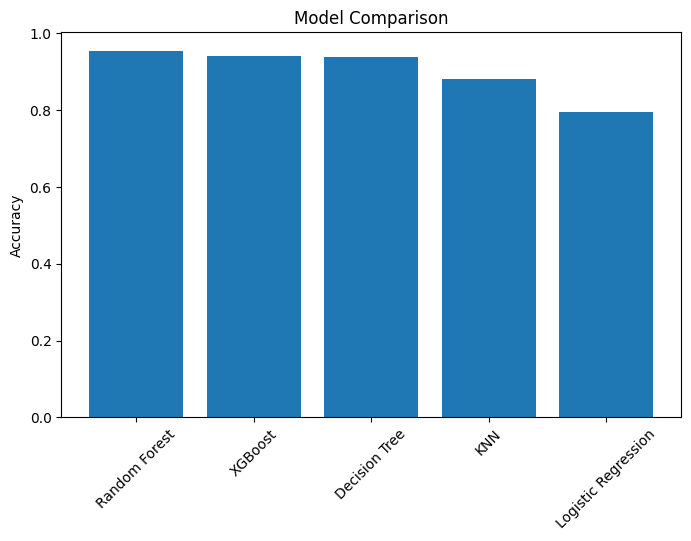

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.xticks(rotation=45)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

Compare models using Accuracy, Confusion Matrix, and Classification Report
metrics.

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Store results
    results.append({
        'Model': name,
        'Accuracy': acc
    })

    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Model: Random Forest
Accuracy: 0.9556

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       614
           1       0.94      0.94      0.94       432
           2       0.81      0.81      0.81       432
           3       0.90      0.98      0.94       432
           4       0.98      0.97      0.97     20614
           5       0.79      0.85      0.82       432
           6       0.91      0.93      0.92      6222

    accuracy                           0.96     29178
   macro avg       0.88      0.91      0.90     29178
weighted avg       0.96      0.96      0.96     29178


Confusion Matrix:
[[  573     0     6     0    29     6     0]
 [    0   405    11     0     0    16     0]
 [    2    13   348     0     5    64     0]
 [    1     0     0   423     0     0     8]
 [   78     0    17     5 19958     9   547]
 [    3    13    47     0     3   366     0]
 [   20     0     3    43   347     0  5809]]

Mode

In [31]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("\nModel Comparison:")
print(results_df)


Model Comparison:
                 Model  Accuracy
0        Random Forest  0.955583
1        Decision Tree  0.925972
4              XGBoost  0.919528
3                  KNN  0.839468
2  Logistic Regression  0.675269


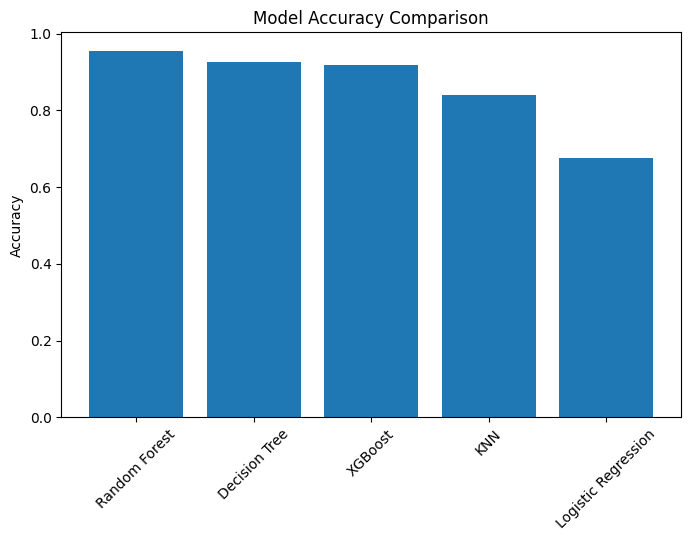

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

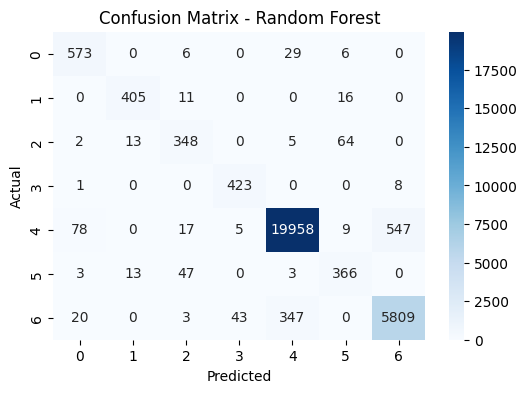

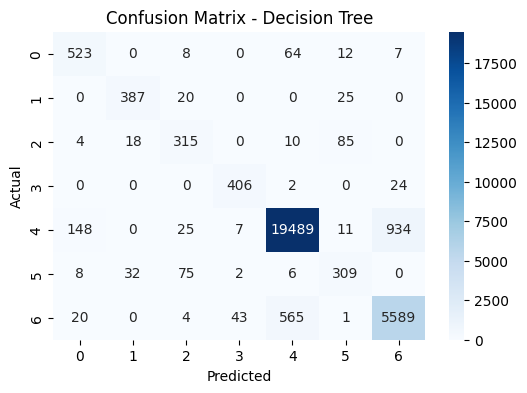

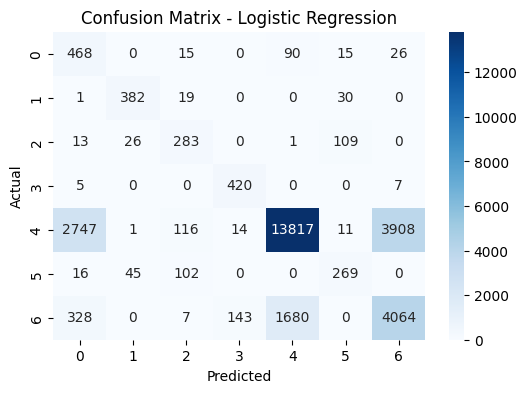

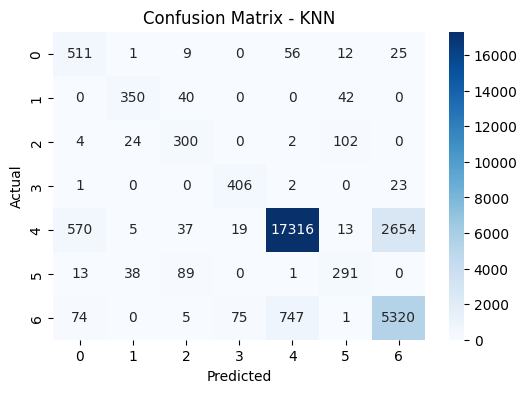

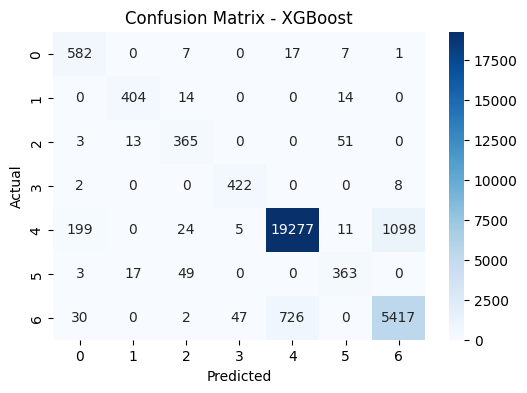

In [33]:
import seaborn as sns

for name, model in models.items():
    y_pred = model.predict(X_test)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

:##🔹 Save Model & Preprocessors

Compare models using Accuracy, Confusion Matrix, and Classification Report
metrics.::

| Model                   | Accuracy  |
| ----------------------- | --------- |
| 🥇 **Random Forest**    | **0.951** |
| 🥈 XGBoost              | 0.949     |
| 🥉 Decision Tree        | 0.938     |
| 4️⃣ KNN                 | 0.886     |
| 5️⃣ Logistic Regression | 0.804     |


| Model                   | Precision | Recall | F1-score |
| ----------------------- | --------- | ------ | -------- |
| 🥇 Random Forest        | 0.90      | 0.89   | **0.89** |
| 🥈 XGBoost              | 0.88      | 0.88   | **0.88** |
| 🥉 Decision Tree        | 0.86      | 0.86   | **0.86** |
| 4️⃣ KNN                 | 0.79      | 0.77   | **0.78** |
| 5️⃣ Logistic Regression | 0.75      | 0.67   | **0.70** |


Interpretation
✅ Random Forest


Best balance of precision & recall


Handles most classes well


Slight weakness in minority classes



🚀 XGBoost


Very close to Random Forest


Strong generalization



🌳 Decision Tree


Good accuracy


Lower macro score → some overfitting



📍 KNN


Moderate performance


Struggles with minority classes



📉 Logistic Regression


Poor recall for small classes


Not suitable for non-linear data



🔥 3. Confusion Matrix Insights (Important)
✔ Strong Models (Random Forest, XGBoost)


High diagonal values → correct predictions ✅


Fewer misclassifications



❗ Common Issues Across Models


Class 4 dominates predictions


Minority classes (0, 2, 5) are often misclassified


👉 Due to class imbalance


🎯 5. Final Comparison Summary
CriteriaBest ModelHighest AccuracyRandom ForestBest Balance (F1)Random ForestClose CompetitorXGBoostSimplest ModelDecision TreeWeakest ModelLogistic Regression

🏁 Final Conclusion
👉 Random Forest is the best-performing model
✔ Highest accuracy
✔ Best macro F1
✔ Stable across classes
👉 XGBoost is a strong alternative

🚀 Recommendation

Use Random Forest for deployment


Hyperparameter Tuning

● Perform hyperparameter tuning (GridSearchCV / RandomizedSearchCV) on the
best-performing model to optimize accuracy and generalization.

In [34]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

In [ ]:
#a

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=2,  # number of combinations
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 3 folds for each of 2 candidates, totalling 6 fits


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=2,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

In [ ]:
best_model = random_search.best_estimator_

best_model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score

y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
# Before tuning
base_model = RandomForestClassifier(random_state=42)
base_model.fit(X_train, y_train)

base_acc = base_model.score(X_test, y_test)

# After tuning
tuned_acc = best_model.score(X_test, y_test)

print("Before Tuning:", base_acc)
print("After Tuning:", tuned_acc)

In [ ]:
#Bonus: Pipeline + Tuning (Best Practice)
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=3)
grid_search.fit(X_train, y_train)

Choose the best-performing model based on evaluation metrics.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# Store results
results = []
trained_models = {}

# Loop through models
for name, model in models.items():
    print(f"\n===== {name} =====")

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')  # important for multi-class

    print("Accuracy:", acc)
    print("F1 Score:", f1)

    # Store results
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1
    })

    trained_models[name] = model

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Sort by best metric (F1 Score recommended)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print("\nModel Comparison:")
print(results_df)

# Select best model
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("\nBest Model Selected:", best_model_name)

Finalize and Save Best Model

Save this trained model as a .pkl file for deployment. (pickle /joblib)

In [ ]:
import joblib

# Save trained model
joblib.dump(best_model, "best_model.pkl")

print("Model saved successfully!")

In [ ]:
import joblib

loaded_model = joblib.load("best_model.pkl")

# Use it
y_pred = loaded_model.predict(X_test)

In [ ]:
from sklearn.pipeline import Pipeline
import joblib

# Example: combine preprocessing + model
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),   # your preprocessing step
    ('model', best_model)
])

# Train pipeline
final_pipeline.fit(X_train, y_train)

# Save pipeline
joblib.dump(final_pipeline, "full_pipeline.pkl")

print("Full pipeline saved!")

In [ ]:
pipeline = joblib.load("full_pipeline.pkl")

# Direct prediction (no manual preprocessing)
y_pred = pipeline.predict(X_test)